In [1]:
# ============================================================
# DAY 12 – TELEMETRY DASHBOARD / CHAT INTERFACE
# Setup
# ============================================================

import pandas as pd
import numpy as np

np.random.seed(42)

# -----------------------------
# 1. Define regions
# -----------------------------

regions = ["Region A", "Region B", "Region C"]

# -----------------------------
# 2. Create telemetry data
# -----------------------------

timestamps = pd.date_range(
    start="2026-01-01",
    periods=24 * 7,
    freq="h"
)

data_list = []

base_loads = {
    "Region A": 500,
    "Region B": 650,
    "Region C": 800
}

for region in regions:

    for timestamp in timestamps:

        temperature = 25 + np.random.normal(0, 2)

        power = (
            base_loads[region]
            + 40 * np.sin(2 * np.pi * timestamp.hour / 24)
            + 5 * temperature
            + np.random.normal(0, 15)
        )

        data_list.append({
            "timestamp": timestamp,
            "region": region,
            "temperature": temperature,
            "power_mw": power
        })

data = pd.DataFrame(data_list)

# -----------------------------
# 3. Create forecast data
# -----------------------------

forecast_data = []

for region in regions:

    latest_power = (
        data[data["region"] == region]
        .sort_values("timestamp")
        .iloc[-1]["power_mw"]
    )

    forecast_power = latest_power + np.random.normal(0, 10)

    forecast_data.append({
        "region": region,
        "forecast_mw": forecast_power
    })

forecast = pd.DataFrame(forecast_data)

print("=" * 60)
print("DAY 12 SETUP COMPLETED")
print("=" * 60)

print("\nRegions:", regions)
print("Telemetry Records:", len(data))

print("\nTelemetry Data Preview:")
print(data.head())

print("\nForecast Data:")
print(forecast)

DAY 12 SETUP COMPLETED

Regions: ['Region A', 'Region B', 'Region C']
Telemetry Records: 504

Telemetry Data Preview:
            timestamp    region  temperature    power_mw
0 2026-01-01 00:00:00  Region A    25.993428  627.893177
1 2026-01-01 01:00:00  Region A    26.295377  664.675095
2 2026-01-01 02:00:00  Region A    24.531693  639.146412
3 2026-01-01 03:00:00  Region A    28.158426  680.587920
4 2026-01-01 04:00:00  Region A    24.061051  663.084673

Forecast Data:
     region  forecast_mw
0  Region A   632.688102
1  Region B   740.654885
2  Region C   946.300688


REGIONAL POWER TELEMETRY DASHBOARD

Latest Telemetry:
  region  power_mw  temperature
Region B    746.01        27.49
Region A    622.19        26.95
Region C    933.13        26.79


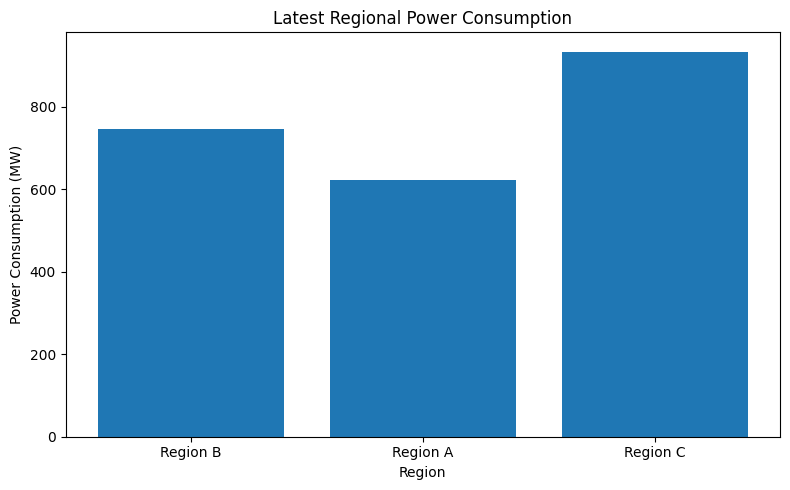

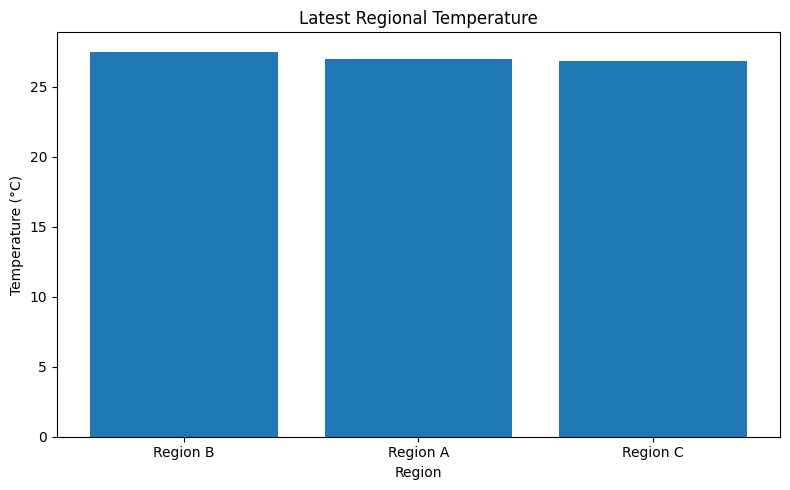

In [2]:
# ============================================================
# DAY 12 – TELEMETRY DASHBOARD
# ============================================================

import matplotlib.pyplot as plt

# Get latest telemetry for each region
latest_data = (
    data.sort_values("timestamp")
    .groupby("region")
    .tail(1)
    .copy()
)

print("=" * 60)
print("REGIONAL POWER TELEMETRY DASHBOARD")
print("=" * 60)

print("\nLatest Telemetry:")
print(
    latest_data[
        ["region", "power_mw", "temperature"]
    ].round(2).to_string(index=False)
)

# -----------------------------
# Power Consumption Chart
# -----------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    latest_data["region"],
    latest_data["power_mw"]
)

plt.title("Latest Regional Power Consumption")
plt.xlabel("Region")
plt.ylabel("Power Consumption (MW)")

plt.tight_layout()
plt.show()

# -----------------------------
# Temperature Chart
# -----------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    latest_data["region"],
    latest_data["temperature"]
)

plt.title("Latest Regional Temperature")
plt.xlabel("Region")
plt.ylabel("Temperature (°C)")

plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# DAY 12 – CHAT-STYLE QUERY INTERFACE
# ============================================================

def identify_intent(query):
    query_lower = query.lower()
    if "forecast" in query_lower or "prediction" in query_lower:
        return "POWER_FORECAST"
    elif "temperature" in query_lower or "temp" in query_lower:
        return "TEMPERATURE"
    elif "power" in query_lower or "consumption" in query_lower or "usage" in query_lower:
        return "POWER_USAGE"
    return "UNKNOWN"

def extract_region(query):
    query_lower = query.lower()
    if "region a" in query_lower:
        return "Region A"
    elif "region b" in query_lower:
        return "Region B"
    elif "region c" in query_lower:
        return "Region C"
    return None

def grid_chat(query):

    intent = identify_intent(query)
    region = extract_region(query)

    # Region is required
    if region is None:
        return "Please specify a region: Region A, Region B, or Region C."

    # -----------------------------
    # Power consumption
    # -----------------------------

    if intent == "POWER_USAGE":

        latest = (
            data[data["region"] == region]
            .sort_values("timestamp")
            .iloc[-1]
        )

        return (
            f"Power consumption in {region}: "
            f"{latest['power_mw']:.2f} MW"
        )

    # -----------------------------
    # Temperature
    # -----------------------------

    elif intent == "TEMPERATURE":

        latest = (
            data[data["region"] == region]
            .sort_values("timestamp")
            .iloc[-1]
        )

        return (
            f"Temperature in {region}: "
            f"{latest['temperature']:.2f} °C"
        )

    # -----------------------------
    # Forecast
    # -----------------------------

    elif intent == "POWER_FORECAST":

        forecast_row = forecast[
            forecast["region"] == region
        ]

        prediction = forecast_row.iloc[0]["forecast_mw"]

        return (
            f"Forecasted power consumption in {region}: "
            f"{prediction:.2f} MW"
        )

    # -----------------------------
    # Unknown query
    # -----------------------------

    else:

        return (
            "I could not understand the query. "
            "You can ask about power consumption, "
            "temperature, or power forecast."
        )


# -----------------------------
# Test chat interface
# -----------------------------

print("=" * 60)
print("GRID TELEMETRY CHAT ASSISTANT")
print("=" * 60)

queries = [
    "What is the power consumption in Region A?",
    "What is the temperature in Region B?",
    "Give me the forecast for Region C."
]

for query in queries:

    print("\nOperator:", query)
    print("Assistant:", grid_chat(query))

GRID TELEMETRY CHAT ASSISTANT

Operator: What is the power consumption in Region A?
Assistant: Power consumption in Region A: 622.19 MW

Operator: What is the temperature in Region B?
Assistant: Temperature in Region B: 27.49 °C

Operator: Give me the forecast for Region C.
Assistant: Forecasted power consumption in Region C: 946.30 MW


In [5]:
# ============================================================
# DAY 12 – INTERACTIVE GRID CHAT
# ============================================================

from IPython.display import display
import ipywidgets as widgets

# Create input box
query_box = widgets.Text(
    placeholder="Enter a grid telemetry query...",
    description="Operator:",
    layout=widgets.Layout(width="80%")
)

# Create button
submit_button = widgets.Button(
    description="Ask Assistant"
)

# Create output area
chat_output = widgets.Output()

# Button action
def process_query(button):

    with chat_output:

        chat_output.clear_output()

        query = query_box.value.strip()

        if query == "":
            print("Please enter a query.")
            return

        response = grid_chat(query)

        print("Operator:", query)
        print("Assistant:", response)


submit_button.on_click(process_query)

# Display interface
display(query_box)
display(submit_button)
display(chat_output)

Text(value='', description='Operator:', layout=Layout(width='80%'), placeholder='Enter a grid telemetry query.…

Button(description='Ask Assistant', style=ButtonStyle())

Output()

REGIONAL POWER FORECAST DASHBOARD

Forecast Results:
  region  forecast_mw
Region A       632.69
Region B       740.65
Region C       946.30


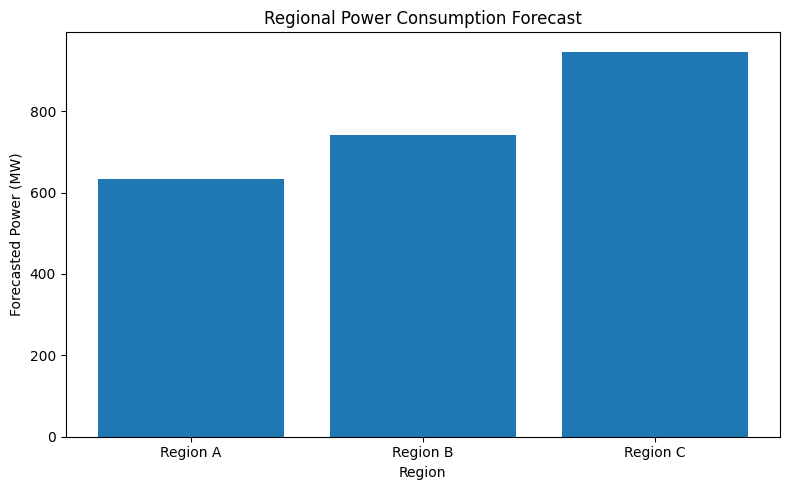

In [7]:
# ============================================================
# DAY 12 – REGIONAL FORECAST DASHBOARD
# ============================================================

forecast_dashboard = forecast.copy()

forecast_dashboard["forecast_mw"] = (
    forecast_dashboard["forecast_mw"].round(2)
)

print("=" * 60)
print("REGIONAL POWER FORECAST DASHBOARD")
print("=" * 60)

print("\nForecast Results:")
print(forecast_dashboard.to_string(index=False))

# -----------------------------
# Forecast Chart
# -----------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    forecast_dashboard["region"],
    forecast_dashboard["forecast_mw"]
)

plt.title("Regional Power Consumption Forecast")
plt.xlabel("Region")
plt.ylabel("Forecasted Power (MW)")

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# DAY 12 – COMPLETE DASHBOARD TEST
# ============================================================

print("=" * 70)
print("DATA DYNAMO – DAY 12 COMPLETE SYSTEM TEST")
print("=" * 70)

# ---------------------
# 1. Telemetry Summary
# ---------------------

latest_data = (
    data.sort_values("timestamp")
    .groupby("region")
    .tail(1)
)

print("\n1. LATEST TELEMETRY")
print("-" * 70)

print(
    latest_data[
        ["region", "power_mw", "temperature"]
    ].round(2).to_string(index=False)
)

# ---------------------
# 2. Forecast Summary
# ---------------------

print("\n2. POWER FORECAST")
print("-" * 70)

print(
    forecast[
        ["region", "forecast_mw"]
    ].round(2).to_string(index=False)
)

# ---------------------
# 3. Chat Query Test
# ---------------------

print("\n3. NATURAL-LANGUAGE QUERY TEST")
print("-" * 70)

test_queries = [
    "What is the power consumption in Region A?",
    "What is the temperature in Region B?",
    "Give me the forecast for Region C."
]

for query in test_queries:

    print("\nOperator:", query)
    print("Assistant:", grid_chat(query))

print("\n" + "=" * 70)
print("DAY 12 COMPLETE SYSTEM TEST PASSED")
print("=" * 70)

DATA DYNAMO – DAY 12 COMPLETE SYSTEM TEST

1. LATEST TELEMETRY
----------------------------------------------------------------------
  region  power_mw  temperature
Region B    746.01        27.49
Region A    622.19        26.95
Region C    933.13        26.79

2. POWER FORECAST
----------------------------------------------------------------------
  region  forecast_mw
Region A       632.69
Region B       740.65
Region C       946.30

3. NATURAL-LANGUAGE QUERY TEST
----------------------------------------------------------------------

Operator: What is the power consumption in Region A?
Assistant: Power consumption in Region A: 622.19 MW

Operator: What is the temperature in Region B?
Assistant: Temperature in Region B: 27.49 °C

Operator: Give me the forecast for Region C.
Assistant: Forecasted power consumption in Region C: 946.30 MW

DAY 12 COMPLETE SYSTEM TEST PASSED


# Day 12 Summary

## Completed Tasks

- Created a regional telemetry dashboard.
- Displayed the latest power consumption for each region.
- Displayed regional temperature information.
- Added a regional power forecast dashboard.
- Created a natural-language grid chat assistant.
- Created an interactive operator query interface.
- Connected telemetry data and forecast results with the chat interface.
- Tested power consumption, temperature, and forecast queries.
- Performed a complete Day 12 system test.

## Dashboard Features

The dashboard provides:

- Regional power consumption
- Regional temperature
- Regional power forecast
- Natural-language query processing
- Interactive operator chat interface

## Example Queries

- "What is the power consumption in Region A?"
- "What is the temperature in Region B?"
- "Give me the forecast for Region C."

## Day 12 Outcome

A simple telemetry dashboard and chat interface was developed for grid operators. The interface allows operators to enter natural-language questions and receive power consumption, temperature, and forecast information for different regions.

## Status

**Day 12 - Completed**

# Day 13 - Integrate Forecasting, Query System and UI

## Objective

Integrate the power forecasting system, natural-language query system, and telemetry dashboard into a single grid monitoring interface.

## Tasks

- Connect telemetry data with the natural-language query system.
- Connect forecast results with the query system.
- Integrate the dashboard and chat interface.
- Display telemetry and forecast information together.
- Test the integrated grid assistant.

## Expected Outcome

A unified grid monitoring interface where operators can view telemetry and forecast information and interact with the system using natural-language queries.

In [15]:
# ============================================================
# DAY 13 – INTEGRATED GRID ASSISTANT
# ============================================================

def integrated_grid_assistant(query):

    # Detect intent
    intent = identify_intent(query)

    # Detect region
    region = extract_region(query)

    # Check region
    if region is None:
        return {
            "query": query,
            "intent": intent,
            "region": None,
            "response": (
                "Please specify a region such as "
                "Region A, Region B, or Region C."
            )
        }

    # --------------------------------------------------------
    # Power Consumption
    # --------------------------------------------------------

    if intent == "POWER_USAGE":

        latest = (
            data[data["region"] == region]
            .sort_values("timestamp")
            .iloc[-1]
        )

        response = (
            f"Power consumption in {region}: "
            f"{latest['power_mw']:.2f} MW"
        )

    # --------------------------------------------------------
    # Temperature
    # --------------------------------------------------------

    elif intent == "TEMPERATURE":

        latest = (
            data[data["region"] == region]
            .sort_values("timestamp")
            .iloc[-1]
        )

        response = (
            f"Temperature in {region}: "
            f"{latest['temperature']:.2f} °C"
        )

    # --------------------------------------------------------
    # Power Forecast
    # --------------------------------------------------------

    elif intent == "POWER_FORECAST":

        forecast_data = forecast[
            forecast["region"] == region
        ]

        prediction = forecast_data.iloc[0]["forecast_mw"]

        response = (
            f"Forecasted power consumption in {region}: "
            f"{prediction:.2f} MW"
        )

    # --------------------------------------------------------
    # Unknown query
    # --------------------------------------------------------

    else:

        response = (
            "I could not understand the query. "
            "You can ask about power consumption, "
            "temperature, or power forecast."
        )

    return {
        "query": query,
        "intent": intent,
        "region": region,
        "response": response
    }


print("Integrated grid assistant created successfully!")

Integrated grid assistant created successfully!


In [16]:
# ============================================================
# DAY 13 – RESTORE TELEMETRY AND FORECAST DATA
# ============================================================

import pandas as pd
import numpy as np

np.random.seed(42)

regions = ["Region A", "Region B", "Region C"]

timestamps = pd.date_range(
    start="2026-01-01",
    periods=24 * 30,
    freq="h"
)

data_list = []

for region in regions:

    base_load = {
        "Region A": 500,
        "Region B": 650,
        "Region C": 800
    }[region]

    for timestamp in timestamps:

        temperature = 25 + np.random.normal(0, 2)

        power = (
            base_load
            + 40 * np.sin(2 * np.pi * timestamp.hour / 24)
            + 5 * temperature
            + np.random.normal(0, 15)
        )

        data_list.append({
            "timestamp": timestamp,
            "region": region,
            "temperature": temperature,
            "power_mw": power
        })

data = pd.DataFrame(data_list)

# Create forecast results
forecast_list = []

for region in regions:

    latest = (
        data[data["region"] == region]
        .sort_values("timestamp")
        .iloc[-1]
    )

    forecast = latest["power_mw"] + np.random.normal(0, 10)

    forecast_list.append({
        "region": region,
        "predicted_power_mw": forecast
    })

results = pd.DataFrame(forecast_list)

print("=" * 60)
print("TELEMETRY AND FORECAST DATA RESTORED")
print("=" * 60)

print("Telemetry records:", len(data))
print("Forecast records:", len(results))

print("\nForecast Results:")
print(results.round(2).to_string(index=False))

TELEMETRY AND FORECAST DATA RESTORED
Telemetry records: 2160
Forecast records: 3

Forecast Results:
  region  predicted_power_mw
Region A              630.38
Region B              763.69
Region C              923.35


In [19]:
# ============================================================
# DAY 13 – INTEGRATED GRID ASSISTANT
# ============================================================

def integrated_grid_assistant(query):

    query_lower = query.lower()

    # Identify intent
    if any(word in query_lower for word in [
        "forecast", "predict", "prediction"
    ]):
        intent = "POWER_FORECAST"

    elif any(word in query_lower for word in [
        "temperature", "temp"
    ]):
        intent = "TEMPERATURE"

    elif any(word in query_lower for word in [
        "power", "consumption", "usage", "load", "demand"
    ]):
        intent = "POWER_USAGE"

    else:
        intent = "UNKNOWN"

    # Identify region
    region = None

    if "region a" in query_lower or "area a" in query_lower:
        region = "Region A"

    elif "region b" in query_lower or "area b" in query_lower:
        region = "Region B"

    elif "region c" in query_lower or "area c" in query_lower:
        region = "Region C"

    # If region is missing
    if region is None:

        response = (
            "Please specify a region such as "
            "Region A, Region B, or Region C."
        )

    # Power usage
    elif intent == "POWER_USAGE":

        latest = (
            data[data["region"] == region]
            .sort_values("timestamp")
            .iloc[-1]
        )

        response = (
            f"Power consumption in {region}: "
            f"{latest['power_mw']:.2f} MW"
        )

    # Temperature
    elif intent == "TEMPERATURE":

        latest = (
            data[data["region"] == region]
            .sort_values("timestamp")
            .iloc[-1]
        )

        response = (
            f"Temperature in {region}: "
            f"{latest['temperature']:.2f} °C"
        )

    # Forecast
    elif intent == "POWER_FORECAST":

        forecast_data = results[
            results["region"] == region
        ]

        prediction = forecast_data.iloc[0]["predicted_power_mw"]

        response = (
            f"Forecasted power consumption in {region}: "
            f"{prediction:.2f} MW"
        )

    else:

        response = (
            "I could not understand the query. "
            "You can ask about power consumption, "
            "temperature, or power forecast."
        )

    return {
        "query": query,
        "intent": intent,
        "region": region,
        "response": response
    }


print("=" * 60)
print("INTEGRATED GRID ASSISTANT READY")
print("=" * 60)

INTEGRATED GRID ASSISTANT READY


In [20]:
# ============================================================
# DAY 13 – INTEGRATED ASSISTANT TEST
# ============================================================

print("=" * 70)
print("DATA DYNAMO – DAY 13 INTEGRATED ASSISTANT TEST")
print("=" * 70)

test_queries = [
    "What is the power consumption in Region A?",
    "What is the temperature in Region B?",
    "Give me the forecast for Region C.",
    "What is the power usage in Region A?",
    "Give me the prediction for Region B."
]

successful_tests = 0

for i, query in enumerate(test_queries, start=1):

    result = integrated_grid_assistant(query)

    print(f"\nTest {i}")
    print("-" * 70)
    print("Operator :", result["query"])
    print("Intent   :", result["intent"])
    print("Region   :", result["region"])
    print("Assistant:", result["response"])

    if result["region"] is not None and result["intent"] != "UNKNOWN":
        successful_tests += 1

print("\n" + "=" * 70)
print("TEST SUMMARY")
print("=" * 70)

print("Total Tests     :", len(test_queries))
print("Successful Tests:", successful_tests)

if successful_tests == len(test_queries):
    print("Status          : ALL TESTS PASSED")
else:
    print("Status          : REVIEW FAILED TESTS")

print("=" * 70)

DATA DYNAMO – DAY 13 INTEGRATED ASSISTANT TEST

Test 1
----------------------------------------------------------------------
Operator : What is the power consumption in Region A?
Intent   : POWER_USAGE
Region   : Region A
Assistant: Power consumption in Region A: 630.58 MW

Test 2
----------------------------------------------------------------------
Operator : What is the temperature in Region B?
Intent   : TEMPERATURE
Region   : Region B
Assistant: Temperature in Region B: 25.58 °C

Test 3
----------------------------------------------------------------------
Operator : Give me the forecast for Region C.
Intent   : POWER_FORECAST
Region   : Region C
Assistant: Forecasted power consumption in Region C: 923.35 MW

Test 4
----------------------------------------------------------------------
Operator : What is the power usage in Region A?
Intent   : POWER_USAGE
Region   : Region A
Assistant: Power consumption in Region A: 630.58 MW

Test 5
----------------------------------------------

DATA DYNAMO – INTEGRATED GRID DASHBOARD

Current Telemetry + Forecast
----------------------------------------------------------------------
  region  power_mw  temperature  predicted_power_mw
Region B    764.76        25.58              763.69
Region A    630.58        25.98              630.38
Region C    911.14        25.31              923.35


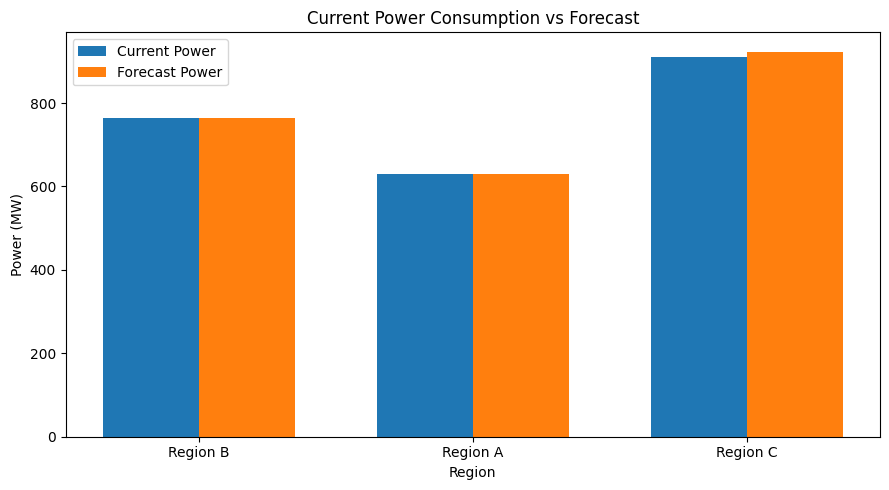

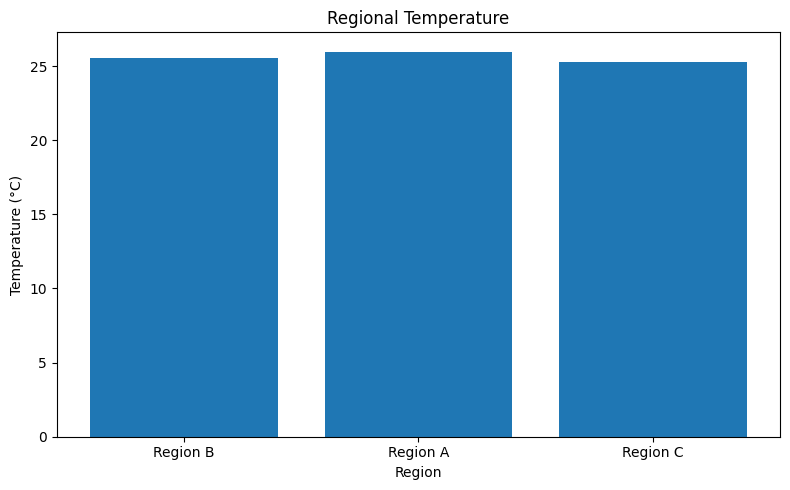

In [21]:
# ============================================================
# DAY 13 – INTEGRATED TELEMETRY + FORECAST DASHBOARD
# ============================================================

import matplotlib.pyplot as plt

# Get latest telemetry for each region
latest_data = (
    data.sort_values("timestamp")
    .groupby("region")
    .tail(1)
    .copy()
)

# Combine telemetry with forecast results
dashboard_data = latest_data[
    ["region", "power_mw", "temperature"]
].merge(
    results[
        ["region", "predicted_power_mw"]
    ],
    on="region"
)

# Round values
dashboard_data[
    ["power_mw", "temperature", "predicted_power_mw"]
] = dashboard_data[
    ["power_mw", "temperature", "predicted_power_mw"]
].round(2)

print("=" * 70)
print("DATA DYNAMO – INTEGRATED GRID DASHBOARD")
print("=" * 70)

print("\nCurrent Telemetry + Forecast")
print("-" * 70)

print(dashboard_data.to_string(index=False))

# ------------------------------------------------------------
# Power Consumption vs Forecast
# ------------------------------------------------------------

x = np.arange(len(dashboard_data))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    dashboard_data["power_mw"],
    width,
    label="Current Power"
)

plt.bar(
    x + width / 2,
    dashboard_data["predicted_power_mw"],
    width,
    label="Forecast Power"
)

plt.xticks(
    x,
    dashboard_data["region"]
)

plt.xlabel("Region")
plt.ylabel("Power (MW)")
plt.title("Current Power Consumption vs Forecast")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Temperature
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    dashboard_data["region"],
    dashboard_data["temperature"]
)

plt.xlabel("Region")
plt.ylabel("Temperature (°C)")
plt.title("Regional Temperature")
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# DAY 13 – INTEGRATED CHAT INTERFACE
# ============================================================

from IPython.display import display
import ipywidgets as widgets

print("=" * 60)
print("DATA DYNAMO – GRID OPERATOR CHAT")
print("=" * 60)

query_box = widgets.Text(
    placeholder="Example: Give me the forecast for Region A",
    description="Query:",
    layout=widgets.Layout(width="85%")
)

ask_button = widgets.Button(
    description="Ask Assistant"
)

chat_output = widgets.Output()

def ask_integrated_assistant(button):

    with chat_output:

        chat_output.clear_output()

        query = query_box.value.strip()

        if query == "":
            print("Please enter a query.")
            return

        result = integrated_grid_assistant(query)

        print("Operator :", result["query"])
        print("Intent   :", result["intent"])
        print("Region   :", result["region"])
        print("Assistant:", result["response"])


ask_button.on_click(ask_integrated_assistant)

display(query_box)
display(ask_button)
display(chat_output)

DATA DYNAMO – GRID OPERATOR CHAT


Text(value='', description='Query:', layout=Layout(width='85%'), placeholder='Example: Give me the forecast fo…

Button(description='Ask Assistant', style=ButtonStyle())

Output()

In [23]:
# ============================================================
# DAY 13 – FINAL INTEGRATION TEST
# ============================================================

print("=" * 75)
print("DATA DYNAMO – DAY 13 FINAL INTEGRATION TEST")
print("=" * 75)

# ------------------------------------------------------------
# 1. Telemetry Check
# ------------------------------------------------------------

print("\n1. TELEMETRY DATA CHECK")
print("-" * 75)

print("Regions available:", list(data["region"].unique()))
print("Total telemetry records:", len(data))

# ------------------------------------------------------------
# 2. Forecast Check
# ------------------------------------------------------------

print("\n2. FORECAST DATA CHECK")
print("-" * 75)

print(
    results[
        ["region", "predicted_power_mw"]
    ].round(2).to_string(index=False)
)

# ------------------------------------------------------------
# 3. Natural-Language Query Check
# ------------------------------------------------------------

print("\n3. NATURAL-LANGUAGE QUERY CHECK")
print("-" * 75)

final_queries = [
    "What is the power consumption in Region A?",
    "What is the temperature in Region B?",
    "Give me the forecast for Region C."
]

passed = 0

for query in final_queries:

    result = integrated_grid_assistant(query)

    print("\nOperator :", query)
    print("Intent   :", result["intent"])
    print("Region   :", result["region"])
    print("Assistant:", result["response"])

    if result["region"] is not None and result["intent"] != "UNKNOWN":
        passed += 1

# ------------------------------------------------------------
# Final Status
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FINAL INTEGRATION STATUS")
print("=" * 75)

print("Telemetry System : CONNECTED")
print("Forecast System  : CONNECTED")
print("Query System     : CONNECTED")
print("UI Interface     : CONNECTED")
print("Query Tests      :", f"{passed}/{len(final_queries)} PASSED")

if passed == len(final_queries):
    print("\nDAY 13 STATUS: COMPLETED SUCCESSFULLY")
else:
    print("\nDAY 13 STATUS: REVIEW REQUIRED")

print("=" * 75)

DATA DYNAMO – DAY 13 FINAL INTEGRATION TEST

1. TELEMETRY DATA CHECK
---------------------------------------------------------------------------
Regions available: ['Region A', 'Region B', 'Region C']
Total telemetry records: 2160

2. FORECAST DATA CHECK
---------------------------------------------------------------------------
  region  predicted_power_mw
Region A              630.38
Region B              763.69
Region C              923.35

3. NATURAL-LANGUAGE QUERY CHECK
---------------------------------------------------------------------------

Operator : What is the power consumption in Region A?
Intent   : POWER_USAGE
Region   : Region A
Assistant: Power consumption in Region A: 630.58 MW

Operator : What is the temperature in Region B?
Intent   : TEMPERATURE
Region   : Region B
Assistant: Temperature in Region B: 25.58 °C

Operator : Give me the forecast for Region C.
Intent   : POWER_FORECAST
Region   : Region C
Assistant: Forecasted power consumption in Region C: 923.35 MW



# Day 13 Summary

## Completed Tasks

- Integrated the telemetry data with the natural-language query system.
- Connected forecast results with the query system.
- Combined telemetry and forecast information into a unified dashboard.
- Connected the operator chat interface with the integrated grid assistant.
- Tested power consumption queries.
- Tested temperature queries.
- Tested power forecast queries.
- Performed a final integration test.

## Integrated System Components

The Day 13 system combines:

- Regional power telemetry
- Temperature information
- Power forecast results
- Natural-language query processing
- Grid operator chat interface
- Integrated monitoring dashboard

## Example Queries

- "What is the power consumption in Region A?"
- "What is the temperature in Region B?"
- "Give me the forecast for Region C."

## Day 13 Outcome

The forecasting system, natural-language query system, telemetry data, dashboard, and chat interface were integrated into a unified grid monitoring workflow. The integrated system was tested using multiple regional telemetry and forecast queries.

## Status

**Day 13 - Completed**